# TinyStories Language Model

This notebook trains a small language model from scratch that learns to generate short stories in the style of children's fiction.

A **language model** is a program that learns to predict the next word in a sentence by reading millions of examples. After training, it can generate new text by repeatedly predicting what comes next one word at a time.

We use the **TinyStories** dataset. It is a collection of over 2 million short children's stories written with simple vocabulary and clear narrative structure. This makes it ideal for training small models, since the patterns are consistent and learnable.

### What happens in each step
1. **Load data** — download stories from the TinyStories dataset
2. **Tokenize** — convert text into numbers the model can process
3. **Build sequences** — create input/target pairs for training
4. **Define model** — build the transformer neural network
5. **Train** — run the training loop and monitor progress
6. **Generate** — use the trained model to write new stories

### Requirements
Install these before running (only needed once per container):
```
pip install sentencepiece datasets ftfy
```

## Cell 1 Setup

This cell imports all the libraries we need and detects whether a GPU is available.

- **GPU** (graphics card) training is much faster than CPU training. If a GPU is found, we enable **mixed precision** — a technique that uses 16-bit numbers instead of 32-bit for most calculations, roughly doubling speed on modern GPUs without affecting quality.
- If no GPU is found the model will still train, just slower.

In [1]:
import os, sys, logging, tempfile, re

# These must be set before importing Keras
os.environ['KERAS_BACKEND']        = 'tensorflow'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # Suppress noisy TF logs
os.environ['CUDA_DEVICE_ORDER']    = 'PCI_BUS_ID'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import numpy as np
import tensorflow as tf
import keras
import sentencepiece as spm
import ftfy
import matplotlib.pyplot as plt
from datasets import load_dataset

# Detect GPU and configure accordingly
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU detected: {gpus[0].name}")
    # Mixed precision: uses 16-bit numbers for compute (faster on Tensor Core GPUs)
    # but keeps weights in 32-bit (more accurate). ~2x speedup on RTX cards.
    keras.mixed_precision.set_global_policy('mixed_float16')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    DEVICE = 'GPU'
else:
    print("No GPU detected — running on CPU (training will be slower)")
    keras.mixed_precision.set_global_policy('float32')
    DEVICE = 'CPU'

print(f"Keras {keras.__version__} | Backend: {keras.config.backend()} | Device: {DEVICE} | Precision: {keras.mixed_precision.global_policy().name}")

GPU detected: /physical_device:GPU:0
Keras 3.0.5 | Backend: tensorflow | Device: GPU | Precision: mixed_float16


## Cell 2 Load TinyStories

We download stories from the TinyStories dataset hosted on Hugging Face. The full dataset has over 2 million stories. We are using a subset to keep training manageable.

Each story is separated by a special `<|endoftext|>` token so the model learns where one story ends and the next begins. This prevents the model from generating text that awkwardly bridges two unrelated stories.

We also fix encoding artifacts (like `â€TM` appearing instead of `'`) using the `ftfy` library.

**Adjusting story count:** Change `MAX_STORIES` to control how much data to use. More stories = better quality but longer training time.

In [2]:
MAX_STORIES = 50000  # Increase for better quality, decrease for faster experimentation

print(f"Downloading TinyStories ({MAX_STORIES:,} stories)...")
ds = load_dataset("roneneldan/TinyStories", split="train")

# Fix encoding artifacts and join with separator tokens
texts = [ftfy.fix_text(t) for t in ds['text'][:MAX_STORIES]]
full_corpus = "\n<|endoftext|>\n".join(texts)

print(f"Stories loaded:    {MAX_STORIES:,}")
print(f"Total characters:  {len(full_corpus):,}")
print(f"\nSample story:\n{texts[0][:400]}")

Stories loaded:    50,000
Total characters:  45,280,779

Sample story:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

To


## Cell 3 Train the tokenizer

Before the model can read text, we need to convert words into numbers. A **tokenizer** does this job.

We use **Byte Pair Encoding (BPE).** It is a method that breaks text into subword pieces. Common words like `"happy"` become a single token, while rare words get split into pieces like `["un", "expect", "ed"]`. This means the model can handle any word, even ones it hasn't seen before.

The `vocab_size` controls how many unique tokens exist. TinyStories uses simple vocabulary so 4000 tokens is sufficient.

SentencePiece requires a file as input, so we write a temporary file, train from it, load the result into memory, then delete the file immediately.

In [3]:
VOCAB_SIZE = 4000

# Write corpus to a temp file (SentencePiece requires a file path, not a string)
with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', encoding='utf-8', delete=False) as tmp:
    tmp.write(full_corpus)
    temp_path = tmp.name

# Suppress verbose training log
devnull = open(os.devnull, 'w')
old_stderr = sys.stderr
sys.stderr = devnull

with tempfile.TemporaryDirectory() as tmpdir:
    model_prefix = os.path.join(tmpdir, 'ts_sp')
    spm.SentencePieceTrainer.train(
        input=temp_path,
        model_prefix=model_prefix,
        vocab_size=VOCAB_SIZE,
        character_coverage=0.9995,
        model_type='bpe',
        pad_id=0, unk_id=1, bos_id=2, eos_id=3,
        user_defined_symbols=['<|endoftext|>'],
    )
    with open(f"{model_prefix}.model", 'rb') as f:
        sp_model_bytes = f.read()

sys.stderr = old_stderr
devnull.close()
os.remove(temp_path)

# Load tokenizer from memory — no files on disk
sp = spm.SentencePieceProcessor()
sp.load_from_serialized_proto(sp_model_bytes)

test = "Once upon a time there was a little girl."
print(f"Test tokenization: {sp.encode_as_pieces(test)}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Test tokenization: ['▁Once', '▁upon', '▁a', '▁time', '▁there', '▁was', '▁a', '▁little', '▁girl', '.']
Vocabulary size: 4000


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /tmp/tmpxhzic3h2.txt
  input_format: 
  model_prefix: /tmp/tmput87kkmm/ts_sp
  model_type: BPE
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <|endoftext|>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  un

## Cell 4 Build training sequences

We convert the full corpus into a long list of numbers (token IDs), then slice it into fixed-length chunks.

Each chunk is split into an **input** and a **target** — the target is the input shifted one position to the right. This trains the model to predict the next token at every position simultaneously:

```
Input:  [Once] [upon] [a]    [time] [there]
Target: [upon] [a]   [time] [there] [was]
```

We use non-overlapping chunks (each chunk starts where the previous one ended) to avoid creating millions of near-identical training examples.

The data is then shuffled and split: 80% for training, 20% for validation. Validation data is never used for training, it lets us check whether the model is learning genuine patterns or just memorizing the training data.

In [4]:
SEQ_LENGTH = 256  # How many tokens the model sees at once when predicting the next token

all_ids = np.array(sp.encode_as_ids(full_corpus), dtype=np.int32)
print(f"Total tokens: {len(all_ids):,}")

# Slice into non-overlapping chunks of SEQ_LENGTH + 1
sequences = np.array([
    all_ids[i : i + SEQ_LENGTH + 1]
    for i in range(0, len(all_ids) - SEQ_LENGTH, SEQ_LENGTH)
], dtype=np.int32)

inputs  = sequences[:, :-1]  # Everything except the last token
targets = sequences[:, 1:]   # Everything except the first token (shifted right by 1)

# Shuffle and split 80/20
indices = np.random.permutation(len(sequences))
split   = int(0.8 * len(sequences))

train_inputs,  train_targets  = inputs[indices[:split]],  targets[indices[:split]]
val_inputs,    val_targets    = inputs[indices[split:]],   targets[indices[split:]]

print(f"Sequences: {len(sequences):,} total — {len(train_inputs):,} train / {len(val_inputs):,} val")
print(f"Input shape: {train_inputs.shape}")

Total tokens: 11,015,188
Sequences: 43,028 total — 34,422 train / 8,606 val
Input shape: (34422, 256)


## Cell 5 Define the model

We build a **decoder-only transformer.** Here's what each part does:

**Embedding layer:** Converts each token ID into a vector of numbers (like a dictionary lookup). The model learns what these vectors should be during training.

**Positional encoding:** Transformers process all words at the same time, so they need extra information about word order. We add a fixed mathematical pattern to each token's vector that encodes its position in the sequence.

**Transformer blocks (repeated `num_layers` times):** Each block has two parts:
- *Attention:* Each word looks at all previous words and decides which ones are most relevant to predicting the next word. A causal mask prevents it from cheating by looking at future words.
- *Feed-forward network:* Applies a learned transformation to each word's representation independently.

**Output layer:** Projects the final representation to a score for each vocabulary token. The highest score = the predicted next token.

### Hyperparameters
These control the size and capacity of the model. Larger values = more powerful but slower to train.

| Parameter | Value | Meaning |
|---|---|---|
| `embed_dim` | 256 | Size of each token's vector representation |
| `num_heads` | 4 | Number of parallel attention mechanisms |
| `ff_dim` | 512 | Size of the hidden layer in the feed-forward network |
| `num_layers` | 4 | Number of transformer blocks stacked on top of each other |

In [5]:
def get_positional_encoding(max_len, d_model):
    """Creates a fixed matrix of position signals using sine and cosine waves.
    Each position gets a unique pattern so the model knows word order."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles    = 1 / (10000 ** (np.arange(d_model)[np.newaxis, :] / d_model))
    enc = positions * angles
    enc[:, 0::2] = np.sin(enc[:, 0::2])  # Even dimensions → sine
    enc[:, 1::2] = np.cos(enc[:, 1::2])  # Odd dimensions  → cosine
    return enc


# Model size — tuned for TinyStories vocabulary and complexity
embed_dim  = 256
num_heads  = 4    # embed_dim must be divisible by num_heads: 256 / 4 = 64
ff_dim     = 512  # Feed-forward hidden size, conventionally 2× embed_dim
num_layers = 4    # Stacked transformer blocks

# Input: sequences of token IDs
inputs = keras.Input(shape=(SEQ_LENGTH,))

# Token embedding: integer ID → dense vector
x = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add position signals and apply dropout for regularization
x = x + get_positional_encoding(SEQ_LENGTH, embed_dim)
x = keras.layers.Dropout(0.1)(x)

# Stack transformer blocks
for _ in range(num_layers):
    # Self-attention: each token looks at all previous tokens
    # use_causal_mask=True prevents looking at future tokens (essential for generation)
    attn = keras.layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=0.1
    )(x, x, use_causal_mask=True)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attn)

    # Feed-forward: transforms each token's representation independently
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation='gelu'),  # Expand
        keras.layers.Dense(embed_dim),                  # Project back
        keras.layers.Dropout(0.1),
    ])
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn(x))

# Output: score for each vocabulary token at each position
# dtype='float32' keeps logits in full precision even when using mixed precision
outputs = keras.layers.Dense(sp.get_piece_size(), dtype='float32')(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 256)  │  1,024,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256)  │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 256)  │    263,168 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 256)  │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 256)  │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256, 256)  │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 256, 256)  │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,160,416 (15.87 MB)

 Trainable params: 4,160,416 (15.87 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 6 Train the model

Training works by showing the model millions of examples and adjusting its internal numbers (weights) each time it makes a wrong prediction. Over many passes through the data (epochs), it gets progressively better at predicting the next token.

**What to watch:**
- `loss` — how wrong the model's predictions are. Lower is better. Should decrease each epoch.
- `val_loss` — the same measure on data the model hasn't trained on. If this starts going up while training loss keeps falling, the model is overfitting (memorizing rather than learning).
- `accuracy` — what fraction of token predictions are exactly correct. Will be low (30-40%) even for a good model since predicting exact words is hard.

**Callbacks** stop training automatically when it stops improving:
- `EarlyStopping` — stops if `val_loss` hasn't improved for 5 epochs, then restores the best weights
- `ReduceLROnPlateau` — halves the learning rate if progress stalls for 2 epochs

In [6]:
history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=64,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=2, min_lr=1e-6, verbose=1
        ),
    ]
)

Epoch 1/100


I0000 00:00:1776279670.481034  256494 service.cc:145] XLA service 0x7e4bac008c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776279670.481243  256494 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 2070, Compute Capability 7.5
W0000 00:00:1776279671.019455  256494 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1776279682.795123  256556 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_96', 1240 bytes spill stores, 1232 bytes spill loads

I0000 00:00:1776279695.990096  256494 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


537/538 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1046 - loss: 5.9001

W0000 00:00:1776279730.785644  256493 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


538/538 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.1048 - loss: 5.8985

W0000 00:00:1776279754.752907  256493 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1776279758.876193  256494 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1776279761.478000  256769 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_32', 256 bytes spill stores, 256 bytes spill loads



538/538 ━━━━━━━━━━━━━━━━━━━━ 103s 125ms/step - accuracy: 0.1049 - loss: 5.8970 - val_accuracy: 0.2733 - val_loss: 3.8928 - learning_rate: 3.0000e-04
Epoch 2/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 37s 69ms/step - accuracy: 0.2823 - loss: 3.8172 - val_accuracy: 0.3405 - val_loss: 3.3671 - learning_rate: 3.0000e-04
Epoch 3/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 37s 69ms/step - accuracy: 0.3343 - loss: 3.3876 - val_accuracy: 0.3756 - val_loss: 3.0849 - learning_rate: 3.0000e-04
Epoch 4/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 38s 70ms/step - accuracy: 0.3645 - loss: 3.1403 - val_accuracy: 0.3980 - val_loss: 2.9080 - learning_rate: 3.0000e-04
Epoch 5/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 38s 70ms/step - accuracy: 0.3850 - loss: 2.9728 - val_accuracy: 0.4155 - val_loss: 2.7759 - learning_rate: 3.0000e-04
Epoch 6/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 38s 71ms/step - accuracy: 0.3996 - loss: 2.8534 - val_accuracy: 0.4286 - val_loss: 2.6771 - learning_rate: 3.0000e-04
Epoch 7/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 38s 71ms/step -

## Cell 7 Plot training history

Visualizing the training curves helps diagnose whether training went well.

**Healthy training:** Both curves decrease steadily and stay close together.

**Overfitting:** Training loss keeps falling but validation loss starts rising — the model memorized the training data instead of learning general patterns. Fix: add more data or increase dropout.

**Underfitting:** Both curves plateau early at a high loss — the model isn't learning enough. Fix: more epochs, larger model, or lower learning rate.

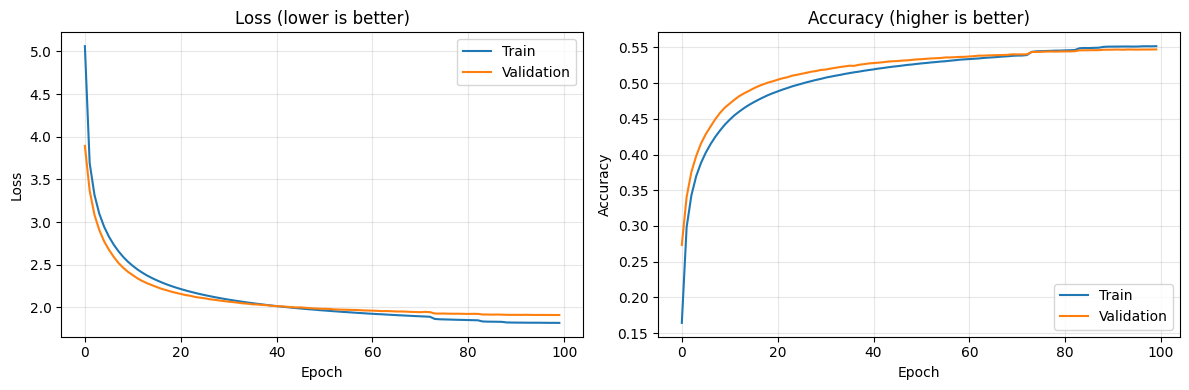

Best val_loss: 1.9104 at epoch 100


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('Loss (lower is better)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Train')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_title('Accuracy (higher is better)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best val_loss: {min(history.history['val_loss']):.4f} at epoch {history.history['val_loss'].index(min(history.history['val_loss'])) + 1}")

## Cell 8 Text generation function

To generate text, we feed the model a **prompt** and ask it to predict the next token. We then append that token to the input, predict the next one, and repeat.

**Temperature** controls how creative vs. predictable the output is:
- `0.6–0.7` — conservative, grammatically safe, can be repetitive
- `0.8` — good balance of coherence and variety (recommended)
- `1.0+` — more surprising and creative, sometimes incoherent

**Top-p (nucleus) sampling** filters out unlikely tokens before sampling. With `top_p=0.9`, we only consider tokens that together account for 90% of the probability — this removes nonsense low-probability words while keeping natural variation. This is why the model stopped generating words like `"corquoalalfanges"`.

**Sliding window:** The model can only see `SEQ_LENGTH` tokens at a time. As generation continues, we drop the oldest token and add the newest — like a sliding window moving through the generated text.

In [8]:
def generate_text(model, sp, prompt, num_tokens=150, temperature=0.8, top_p=0.9):
    """
    Generate text from a prompt using temperature + top-p sampling.

    Args:
        prompt:      Starting text
        num_tokens:  How many new tokens to generate
        temperature: Creativity control (0.7=safe, 0.8=balanced, 1.0=creative)
        top_p:       Only sample from tokens covering this fraction of probability (0.9 recommended)
    """
    input_ids = sp.encode_as_ids(prompt)

    # Pad with zeros if prompt is shorter than SEQ_LENGTH, truncate if longer
    if len(input_ids) < SEQ_LENGTH:
        padding = SEQ_LENGTH - len(input_ids)
        input_ids = [0] * padding + input_ids
    else:
        padding = 0
        input_ids = input_ids[-SEQ_LENGTH:]

    generated_ids = list(input_ids[padding:])

    # Never sample these special control tokens
    banned = {
        sp.piece_to_id('<unk>'),
        sp.piece_to_id('<pad>'),
        sp.piece_to_id('<s>'),
        sp.piece_to_id('</s>'),
        sp.piece_to_id('<|endoftext|>'),  # Stop at story boundaries
    }

    for _ in range(num_tokens):
        predictions = model.predict(np.array([input_ids]), verbose=0)[0]
        logits = predictions[-1] / temperature

        for bid in banned:
            logits[bid] = -np.inf

        # Softmax to get probabilities
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)

        # Top-p filtering: keep only the most probable tokens summing to top_p
        sorted_idx   = np.argsort(probs)[::-1]
        sorted_probs = probs[sorted_idx]
        cutoff       = np.searchsorted(np.cumsum(sorted_probs), top_p) + 1
        top_idx      = sorted_idx[:cutoff]
        top_probs    = sorted_probs[:cutoff] / sorted_probs[:cutoff].sum()

        next_token = int(np.random.choice(top_idx, p=top_probs))
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]  # Slide window forward

    text = sp.decode([int(i) for i in generated_ids])
    # Fix broken contractions like "Snape 's" → "Snape's"
    text = re.sub(r"\b(\w+)\s+'(s|t|ve|re|ll|d|m)\b", r"\1'\2", text)
    return text

## Cell 9 Generate stories

Now we test the model with several prompts. Each prompt gives the model a starting context and it continues the story from there.

TinyStories follows consistent patterns — most stories start with `"Once upon a time"` or introduce a named child character and a simple problem. Prompts that match this pattern tend to produce the most coherent output.

Feel free to add your own prompts to the list and experiment with different `temperature` and `top_p` values.

In [9]:
prompts = [
"Once upon a time there was a young boy who",
"Once upon a time there lived a girl who",
"Once upon a time there was a small dragon who",
"Once upon a time there was an old man who",
"Once upon a time there was a curious child who",
"Once upon a time there was a lonely cat who",
]

for prompt in prompts:
    print(f"{'─' * 60}")
    print(f"Prompt: {prompt}\n")
    print(generate_text(model, sp, prompt, num_tokens=100, temperature=0.8, top_p=0.9))
    print()

────────────────────────────────────────────────────────────
Prompt: Once upon a time there was a young boy who



I0000 00:00:1776283656.904373  262161 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_32', 256 bytes spill stores, 256 bytes spill loads



Once upon a time there was a young boy who was very curious. He wanted to know how many university were. So he asked his mom what they were called university. His mom explained that some university was to learn something new and fun. The young boy was very interested and he wanted to learn more. He asked his mom if he could do that. His mom said yes, so he could learn more. The young boy was so excited! He was eager to learn more about university and learn more

────────────────────────────────────────────────────────────
Prompt: Once upon a time there lived a girl who

Once upon a time there lived a girl who loved to explore. One day she decided to explore the world around her. She was walking along the sidewalk when she saw a bridge. She was amazed at how tall it was. The girl kept walking and soon came across an old, scary bridge. She was scared but she kept going until she saw a beautiful sight. It was so beautiful and it made her feel safe. She also continued exploring the bridge,

## Cell 10 Save model and tokenizer (optional)

Everything has been kept in memory up to this point, nothing has been written to disk. Run this cell when you are happy with the results.

Two files will be saved:
- `ts_model.keras` — the full model (architecture + learned weights)
- `ts_sp.model` — the tokenizer

Both files are needed to reload and use the model in a future session (see Cell 12).

In [10]:
model.save('ts_model.keras')
print("Model saved as 'ts_model.keras'")

with open('ts_sp.model', 'wb') as f:
    f.write(sp_model_bytes)
print("Tokenizer saved as 'ts_sp.model'")

Model saved as 'ts_model.keras'
Tokenizer saved as 'ts_sp.model'


## Cell 12 — Reload in a new session (optional)

If you have saved the model and want to generate text without retraining, run Cell 1 first (for imports and GPU setup), then uncomment and run this cell. You can then skip straight to Cell 8 and 9.

In [11]:
# Uncomment everything below to load a previously saved model

"""
SEQ_LENGTH = 256

with open('ts_sp.model', 'rb') as f:
    sp_model_bytes = f.read()

sp = spm.SentencePieceProcessor()
sp.load_from_serialized_proto(sp_model_bytes)

model = keras.models.load_model('ts_model.keras')

print(f"Model loaded. Vocabulary size: {sp.get_piece_size()}")
"""

'\nSEQ_LENGTH = 256\n\nwith open(\'ts_sp.model\', \'rb\') as f:\n    sp_model_bytes = f.read()\n\nsp = spm.SentencePieceProcessor()\nsp.load_from_serialized_proto(sp_model_bytes)\n\nmodel = keras.models.load_model(\'ts_model.keras\')\n\nprint(f"Model loaded. Vocabulary size: {sp.get_piece_size()}")\n'